In [1]:
import pandas as pd
import random

In [2]:
import pandas as pd
import random

class SimpleRLProductionSystem:
    def __init__(self, max_inventory, min_inventory, max_production, max_demand, backorder_cost, epsilon=0.1):
        self.max_inventory = max_inventory
        self.min_inventory = min_inventory  # Minimum inventory (negative number for backorders)
        self.max_production = max_production
        self.max_demand = max_demand
        self.backorder_cost = backorder_cost  # Cost per unit of backorder
        self.epsilon = epsilon
        self.max_forecast = max_demand
        self.data = pd.DataFrame(columns=['State', 'Demand', 'Forecast', 'Action', 'Reward'])
        self._initialize_data()
        self.current_inventory = 0
        self.forecast = random.randint(0, self.max_demand)

    def _initialize_data(self):
        rows = []
        for state in range(self.min_inventory, self.max_inventory + 1):
            for demand in range(self.max_demand + 1):
                for forecast in range(self.max_demand + 1):
                    for action in range(self.max_production + 1):
                        rows.append({'State': state, 'Demand': demand, 'Forecast': forecast, 'Action': action, 'Reward': float('-inf')})
        self.data = pd.concat([self.data, pd.DataFrame(rows)], ignore_index=True)

    def choose_action(self, state, demand, forecast):
        if random.uniform(0, 1) < self.epsilon:
            return random.randint(0, self.max_production)  # Explore
        else:
            state_demand_data = self.data[(self.data['State'] == state) & (self.data['Forecast'] == forecast) & (self.data['Demand'] == demand)]
            return state_demand_data.loc[state_demand_data['Reward'].idxmax()]['Action']  # Exploit

    def get_reward(self, state, action, demand, forecast):
        new_inventory = state + action - demand

        # Adjust reward calculation to handle backorders and inventory limits
        if new_inventory < self.min_inventory:
            # Penalize for exceeding maximum backorders
            #return -20 - (self.backorder_cost * abs(new_inventory - self.min_inventory))\
            return -80
        elif new_inventory < 0:
            # Penalize for backorders
            return -10 * abs(new_inventory) * self.backorder_cost 
        else:
            if new_inventory > self.max_inventory:
                return -20  # Penalize for exceeding capacity
            else:
                Extra_Inv_need = new_inventory - (max(0,forecast - self.max_production))
                if Extra_Inv_need > 0:
                    return 10 - abs(new_inventory - Extra_Inv_need - 3)
                else:
                    return 10 - abs(new_inventory - 3)  # Reward for meeting demand and maintaining saftey stock of 3 units
            

    def update_data(self, state, demand, forecast, action, reward):
        row_index = self.data[(self.data['State'] == state) & (self.data['Demand'] == demand) & (self.data['Forecast'] == forecast) & (self.data['Action'] == action)].index
        if self.data.at[row_index[0], 'Reward'] < reward:
            self.data.at[row_index[0], 'Reward'] = reward

    def simulate(self, episodes):
        for _ in range(episodes):
            state = self.current_inventory
            demand = self.forecast
            forecast = random.randint(0, self.max_demand)
            action = self.choose_action(state, demand,forecast)
            reward = self.get_reward(state, action, demand, forecast)
            self.update_data(state, demand, forecast, action, reward)

            # Update current inventory, keeping it within set limits
            self.current_inventory = max(self.min_inventory, min(self.max_inventory, state + action - demand))
            self.forecast = forecast

    def evaluate_agent(self, episodes):
        total_reward = 0
        demand_met_count = 0
        episode_data = []
        self.current_inventory = 0

        for episode in range(episodes):
            state = self.current_inventory
            demand = self.forecast
            forecast = random.randint(0, self.max_demand)
            action = self.choose_action_test(state, demand,forecast)
            reward = self.get_reward(state, action, demand, forecast)
            total_reward += reward

            # Update current inventory, keeping it within set limits
            self.current_inventory = max(self.min_inventory, min(self.max_inventory, state + action - demand))
            self.forecast = forecast

            if state + action >= demand:
                demand_met_count += 1

            # Store state, demand, action, and reward for each episode
            episode_data.append((episode, state, demand, forecast, action, reward))
            # Printing the demand and action for each episode
            #print(f"Episode {episode + 1}: Demand = {demand}, Action = {action}, State = {state}")
        average_reward = total_reward / episodes
        demand_met_rate = demand_met_count / episodes

        return average_reward, demand_met_rate, episode_data


    def choose_action_test(self, state, demand, forecast):
            state_demand_data = self.data[(self.data['State'] == state) & (self.data['Forecast'] == forecast) & (self.data['Demand'] == demand)]
            return state_demand_data.loc[state_demand_data['Reward'].idxmax()]['Action']  # Exploit


In [3]:
# Example usage
system = SimpleRLProductionSystem(max_inventory=6, min_inventory=-5, max_production=5, max_demand=7, backorder_cost=1)
system.simulate(episodes=250000)
print(system.data)
system.data.to_csv('file1.csv')

     State Demand Forecast Action  Reward
0       -5      0        0      0   -50.0
1       -5      0        0      1   -40.0
2       -5      0        0      2   -30.0
3       -5      0        0      3   -20.0
4       -5      0        0      4   -10.0
...    ...    ...      ...    ...     ...
4603     6      7        7      1    -inf
4604     6      7        7      2    -inf
4605     6      7        7      3    -inf
4606     6      7        7      4    -inf
4607     6      7        7      5    -inf

[4608 rows x 5 columns]


In [10]:
# Evaluate the trained agent and observe output directly from the method
evaluation_episodes = 25  # Set to a smaller number for demonstration
average_reward, demand_met_rate, Episode_data = system.evaluate_agent(evaluation_episodes)

# Print summary statistics
print(f"\nAverage Reward over {evaluation_episodes} evaluation episodes: {average_reward}")
print(f"Demand Met Rate over {evaluation_episodes} evaluation episodes: {demand_met_rate:.2%}")
print(f"Episode data: {Episode_data}")
#episode, state, demand, action, reward


Average Reward over 25 evaluation episodes: -0.04
Demand Met Rate over 25 evaluation episodes: 76.00%
Episode data: [(0, 0, 5, 0, 5, 7), (1, 0, 0, 4, 0, 7), (2, 0, 4, 0, 4, 7), (3, 0, 0, 5, 0, 7), (4, 0, 5, 6, 5, 7), (5, 0, 6, 1, 5, -10), (6, -1, 1, 7, 4, 9), (7, 2, 7, 7, 5, 7), (8, 0, 7, 6, 5, -20), (9, -2, 6, 2, 5, -30), (10, -3, 2, 4, 5, 7), (11, 0, 4, 4, 4, 7), (12, 0, 4, 5, 4, 7), (13, 0, 5, 1, 5, 7), (14, 0, 1, 6, 2, 8), (15, 1, 6, 7, 5, 7), (16, 0, 7, 7, 5, -20), (17, -2, 7, 1, 5, -40), (18, -4, 1, 7, 5, 7), (19, 0, 7, 3, 5, -20), (20, -2, 3, 2, 5, 7), (21, 0, 2, 3, 2, 7), (22, 0, 3, 7, 5, 9), (23, 2, 7, 2, 5, 7), (24, 0, 2, 6, 3, 8)]


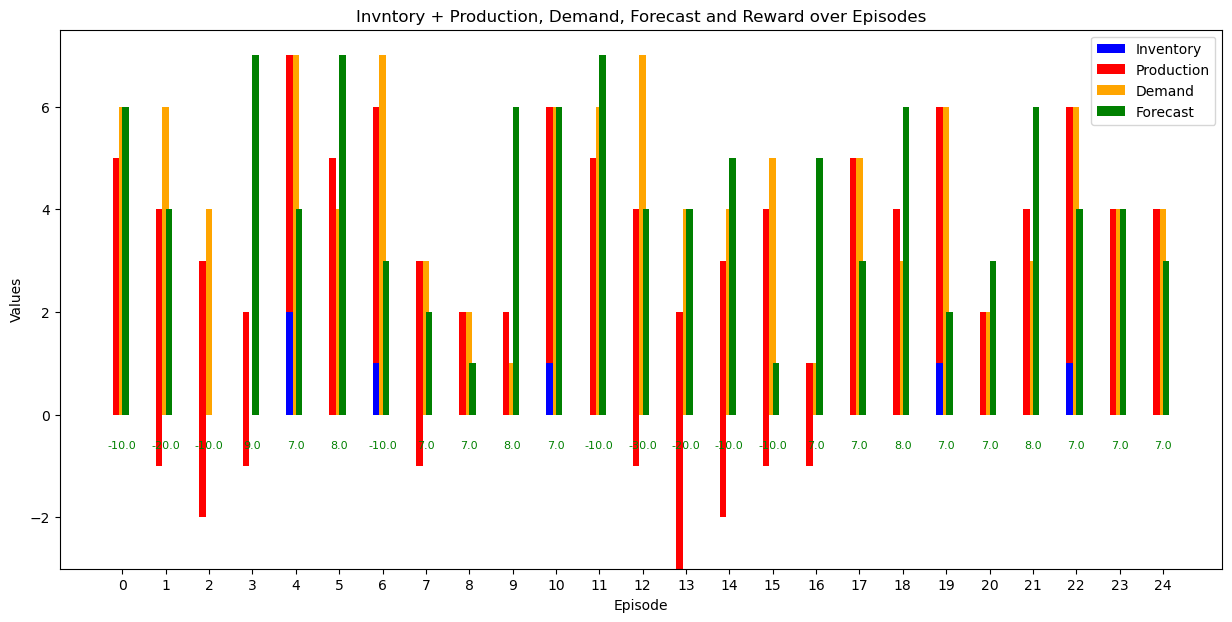

In [12]:
import matplotlib.pyplot as plt
import pandas as pd

# Assuming you have already run the simulation and have the episode_data
average_reward, demand_met_rate, episode_data = system.evaluate_agent(25)

# Convert data to DataFrame for easier plotting
df = pd.DataFrame(episode_data, columns=['Episode', 'State', 'Demand','Forecast', 'Action', 'Reward'])

# Set up the figure
plt.figure(figsize=(15, 7))
width = 0.15  # Width of the bars

# Iterate over episodes to plot bars and add reward text
for i in range(len(df)):
    # State + Action stacked bar
    plt.bar(i - width, df.loc[i, 'State'], width, label='Inventory' if i == 0 else "", color='blue')
    plt.bar(i - width, df.loc[i, 'Action'], width, bottom=df.loc[i, 'State'], label='Production' if i == 0 else "", color='red')

    # Demand bar
    plt.bar(i, df.loc[i, 'Demand'], width, label='Demand' if i == 0 else "", color='orange')

    # Forecast bar
    plt.bar(i + width/2, df.loc[i, 'Forecast'], width, label='Forecast' if i == 0 else "", color='green')

    # Add reward text
    reward = df.loc[i, 'Reward']
    plt.text(i, -0.5, f'{reward:.1f}', ha='center', va='top', color='green', fontsize=8)

# Add labels and title
plt.xlabel('Episode')
plt.ylabel('Values')
plt.title('Invntory + Production, Demand, Forecast and Reward over Episodes')
plt.xticks(range(len(df)), df['Episode'])

# Add legend
plt.legend()

# Show plot
plt.show()


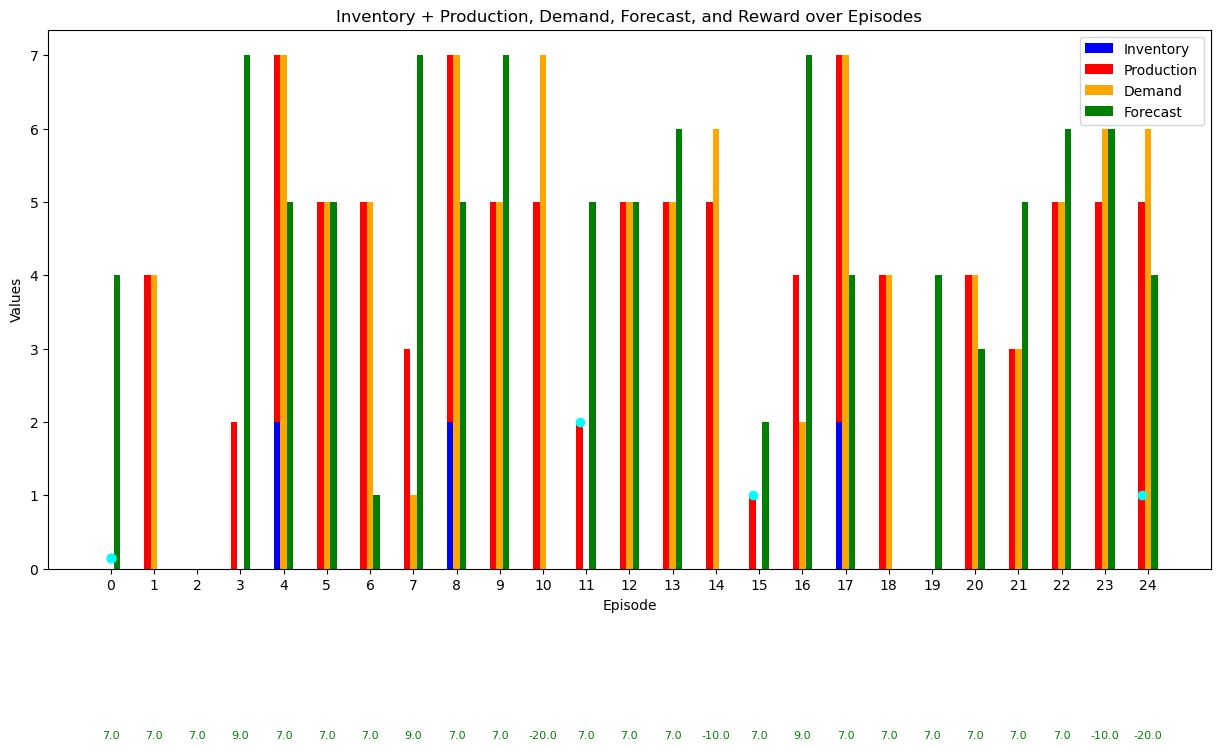

In [23]:
import matplotlib.pyplot as plt
import pandas as pd

# Assuming you have already run the simulation and have the episode_data
average_reward, demand_met_rate, episode_data = system.evaluate_agent(25)

# Convert data to DataFrame for easier plotting
df = pd.DataFrame(episode_data, columns=['Episode', 'State', 'Demand', 'Forecast', 'Action', 'Reward'])

# Set up the figure
plt.figure(figsize=(15, 7))
width = 0.15  # Adjust width to fit all bars

# Iterate over episodes to plot bars and add reward text
for i in range(len(df)):
    state = df.loc[i, 'State']
    action = df.loc[i, 'Action']
    demand = df.loc[i, 'Demand']
    forecast = df.loc[i, 'Forecast']

    # Plotting state and action
    if state >= 0:
        plt.bar(i - width, state, width, label='Inventory' if i == 0 else "", color='blue')
    else:
        plt.plot(i - width, abs(state), width, label='Backorder' if i == 0 else "", color='cyan', linestyle='none', marker='o')
    plt.bar(i - width, action, width, bottom=max(state, 0), label='Production' if i == 0 else "", color='red')
    
    # Plotting demand and forecast with adjusted positions
    plt.bar(i, demand, width, label='Demand' if i == 0 else "", color='orange')
    plt.bar(i + width, forecast, width, label='Forecast' if i == 0 else "", color='green')

    # Add reward text
    reward = df.loc[i, 'Reward']
    plt.text(i, df['State'].min() - abs(df['State'].min() * 0.1), f'{reward:.1f}', ha='center', va='top', color='green', fontsize=8)

# Add labels and title
plt.xlabel('Episode')
plt.ylabel('Values')
plt.title('Inventory + Production, Demand, Forecast, and Reward over Episodes')
plt.xticks(range(len(df)), df['Episode'])

# Add legend
plt.legend()

# Show plot
plt.show()


In [ ]:
#Next steps
# 1) Introduce a demand forecast into the state space and reward it for meeting future excess demand
# 2) See if it can switch demand patterns quickly 
# 3) Q-learning implementaion to achive the same result
# 4) Write a LP program of this